In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
def parse_turbostat(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            parts = line.split()
            if not parts:
                continue

            if parts[0] == "CPU":
                if current:
                    samples.append(current)
                continue

            cpu = "system" if parts[0] == "-" else f"cpu{parts[0]}"
            if cpu != "system":
                current[f"{cpu}"] = int(parts[2])
            if len(parts) > 3 and cpu == "system":
                current[f"{cpu}_pkg_watt"] = float(parts[3])

        if current:
            samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df

In [6]:
def parse_pm(filepath):
    samples = []
    current = {}

    with open(filepath) as f:
        for line in f:
            line = line.strip()
            if line.startswith("*** Sampled system activity"):
                if current and any(k.startswith("cpu") for k in current):
                    samples.append(current)
                current = {}
                continue
            if line.startswith("CPU ") and "frequency:" in line:
                parts = line.split()
                current[f"cpu{int(parts[1])}"] = int(parts[3])
                continue
            if line.startswith("CPU Power:"):
                current["system_pkg_watt"] = float(line.split()[2]) / 1000.0

    if current and any(k.startswith("cpu") for k in current):
        samples.append(current)

    df = pd.DataFrame(samples)
    cpu_cols_local = sorted(
        [c for c in df.columns if c.startswith("cpu")],
        key=lambda x: int(x.replace("cpu", ""))
    )
    df["system"] = df[cpu_cols_local].mean(axis=1)
    return df


In [7]:
def prec(df, cols, n, q):
    t = stats.t.ppf(q, df=n - 1)

    cv_df = df[cols].copy()
    cv_df = cv_df.replace(0, np.nan)

    x = cv_df.stack().mean()
    s = cv_df.stack().std()

    cv = (s / x) * 100
    d = t * cv / np.sqrt(n)

    return d

In [8]:
GROUP_COLORS = ["#4C9BE8", "#7FB77E", "#E8A04C", "#B07FE8"]
MEDIAN_COLORS = ["#1F4E79", "#2E5E2C", "#8A5A1A", "#5A3A8A"]


def _build_long(dfs, labels, cpu_groups):
    freq_rows, watt_rows = [], []
    for df, label in zip(dfs, labels):
        df = df.iloc[8:].reset_index(drop=True)
        for group, cols in cpu_groups.items():
            freq = df[cols].replace(0, np.nan).to_numpy().ravel()
            freq_rows.append(pd.DataFrame(
                {"dataset": label, "core": group, "freq": freq[~np.isnan(freq)]}))
        watt_rows.append(pd.DataFrame(
            {"dataset": label, "watt": df["system_pkg_watt"].to_numpy()}))
    return (pd.concat(freq_rows, ignore_index=True),
            pd.concat(watt_rows, ignore_index=True))


def _recolor_medians(ax, group_order, median_palette, ref):
    medians = [ln for ln in ax.lines if mpl.colors.same_color(ln.get_color(), ref)]
    medians.sort(key=lambda ln: np.mean(ln.get_xdata()))
    for i, ln in enumerate(medians):
        ln.set_color(median_palette[group_order[i % len(group_order)]])
        ln.set_linewidth(0.8)


def plot_turbostat(dfs, labels, cpu_groups, power_scale, width, filename):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, (ax1, ax2) = plt.subplots(
            2, 1, figsize=(width, FIG_HEIGHT_3), layout='constrained', sharex=True,
            gridspec_kw={"height_ratios": [2, 1]})

        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.7,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax1, **common)
            _recolor_medians(ax1, group_order, median_palette, MEDIAN_COLORS[0])
            ax1.legend(loc="best", frameon=False, title=None)

        ax1.set_ylim(0, np.ceil(df_freq["freq"].max() / 500) * 500)
        ax1.set_ylabel("Częstotliwość [MHz]")
        ax1.set_xlabel("")

        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4), ax=ax2, **common)
        ax2.set_ylim(0, np.ceil(df_watt["watt"].max() / power_scale) * power_scale)
        ax2.set_ylabel("Pobór mocy [W]")
        ax2.set_xlabel("")

        if len(dfs) > 1:
            plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        plt.savefig(f'../svg/{filename}.svg', facecolor='white')
        plt.show()

In [18]:
def plot_compare(dfs, labels, cpu_groups, filename):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)
    palette = dict(zip(group_order, GROUP_COLORS))
    median_palette = dict(zip(group_order, MEDIAN_COLORS))
    common = dict(linewidth=0.6, fliersize=0.8)

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
        if single:
            sns.boxplot(data=df_freq, x="dataset", y="freq", order=labels,
                        color=GROUP_COLORS[0], width=0.6,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
        else:
            sns.boxplot(data=df_freq, x="dataset", y="freq",
                        hue="core", order=labels, hue_order=group_order,
                        palette=palette, width=0.7,
                        medianprops=dict(color=MEDIAN_COLORS[0], linewidth=1.4),
                        ax=ax, **common)
            _recolor_medians(ax, group_order, median_palette, MEDIAN_COLORS[0])
            ax.legend(loc="best", frameon=False, title=None)

        ax.set_ylim(0, np.ceil(df_freq["freq"].max() / 500) * 500)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Częstotliwość Bzy [MHz]")
        plt.savefig(f'../svg/{filename}_freq_compare.svg', facecolor='white')
        plt.show()

        watt_min = df_watt["watt"].min()
        watt_max = df_watt["watt"].max()
        fig, ax = plt.subplots(figsize=(FIG_WIDTH / 2, FIG_HEIGHT_4), layout='constrained')
        sns.boxplot(data=df_watt, x="dataset", y="watt", order=labels,
                    color="#C0392B", width=0.6,
                    medianprops=dict(color="#7B241C", linewidth=1.4),
                    ax=ax, **common)
        ax.set_ylim(max(np.floor((watt_min - 10) / 5), 0) * 5,
                    np.ceil((watt_max + 10) / 5) * 5)
        ax.set_xlabel("Backend")
        ax.set_ylabel("Pobór mocy pakietu [W]")
        plt.savefig(f'../svg/{filename}_power_compare.svg', facecolor='white')
        plt.show()

In [23]:
def _report_backends(means, *, label, unit, prec):
    grand = means.mean()
    vmin, vmax = means.min(), means.max()
    dev_pct = max(abs(vmin - grand), abs(vmax - grand)) / grand * 100

    print(f"{label} per backend:")
    for backend, val in means.items():
        diff_pct = (val - grand) / grand * 100
        print(f"  {backend:<8} {val:.{prec}f} {unit}  ({diff_pct:+.2f}% od średniej)")
    print(f"Zakres: {vmin:.{prec}f}–{vmax:.{prec}f} {unit} (rozrzut {vmax - vmin:.{prec}f} {unit})")
    print(f"Średnia ze średnich: {grand:.{prec}f} {unit}, maks. odchył od średniej: {dev_pct:.2f}%")
    print()

def compare_backends(dfs, labels, cpu_groups, *, freq_prec=0, watt_prec=2):
    if not isinstance(cpu_groups, dict):
        cpu_groups = {"": cpu_groups}
    group_order = list(cpu_groups.keys())
    single = len(cpu_groups) == 1

    df_freq, df_watt = _build_long(dfs, labels, cpu_groups)

    if single:
        means = df_freq.groupby("dataset")["freq"].mean().reindex(labels)
        _report_backends(means, label="Częstotliwość", unit="MHz", prec=freq_prec)
    else:
        for group in group_order:
            means = (df_freq[df_freq["core"] == group]
                     .groupby("dataset")["freq"].mean().reindex(labels))
            _report_backends(means, label=f"Częstotliwość [{group}]",
                             unit="MHz", prec=freq_prec)

    means = df_watt.groupby("dataset")["watt"].mean().reindex(labels)
    _report_backends(means, label="Pobór mocy", unit="W", prec=watt_prec)

In [11]:
bench_turbostat = parse_turbostat("../data/turbostat-bench.txt")
system_turbostat = parse_turbostat("../data/turbostat-system.txt")
scalar_turbostat = parse_turbostat("../data/turbostat-search-Scalar.txt")
sse2_turbostat = parse_turbostat("../data/turbostat-search-Sse2.txt")
avx2_turbostat = parse_turbostat("../data/turbostat-search-Avx2.txt")
avx512_turbostat = parse_turbostat("../data/turbostat-search-Avx512.txt")
bench_pm = parse_pm("../data/pm-bench.txt")
system_pm_Speck32_64 = parse_pm("../data/pm-system-Speck32_64.txt")
system_pm_Speck48_72 = parse_pm("../data/pm-system-Speck48_72.txt")
system_pm_Speck48_96 = parse_pm("../data/pm-system-Speck48_96.txt")
system_pm_Speck64_96 = parse_pm("../data/pm-system-Speck64_96.txt")
system_pm_Speck64_128 = parse_pm("../data/pm-system-Speck64_128.txt")
system_pm_Speck96_96 = parse_pm("../data/pm-system-Speck96_96.txt")
system_pm_Speck96_144 = parse_pm("../data/pm-system-Speck96_144.txt")
system_pm_Speck128_128 = parse_pm("../data/pm-system-Speck128_128.txt")
system_pm_Speck128_192 = parse_pm("../data/pm-system-Speck128_192.txt")
system_pm_Speck128_256 = parse_pm("../data/pm-system-Speck128_256.txt")
scalar_pm = parse_pm("../data/pm-search-Scalar.txt")
neon_pm = parse_pm("../data/pm-search-Neon.txt")

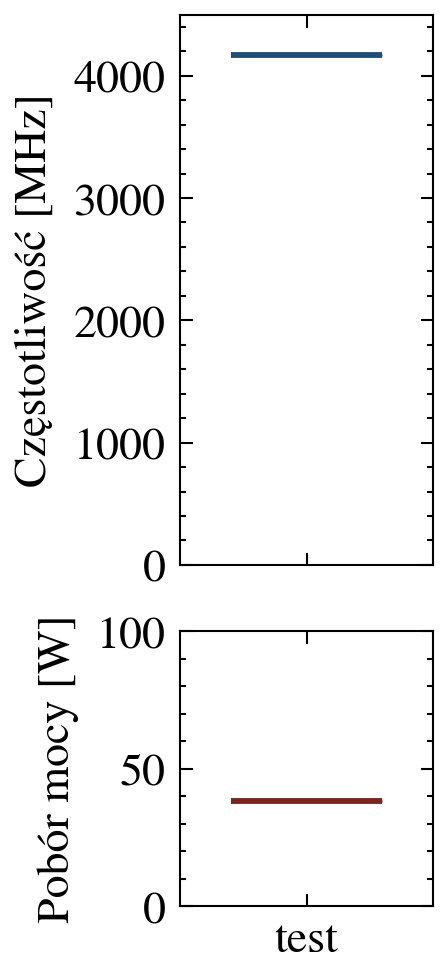

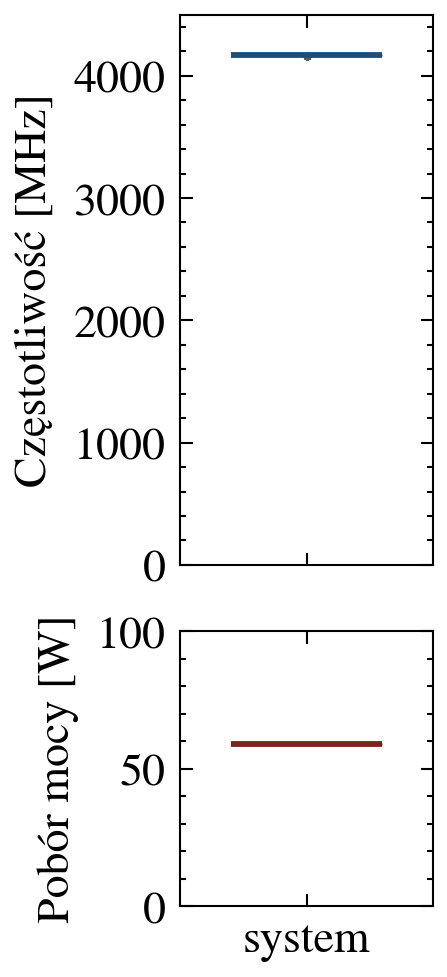

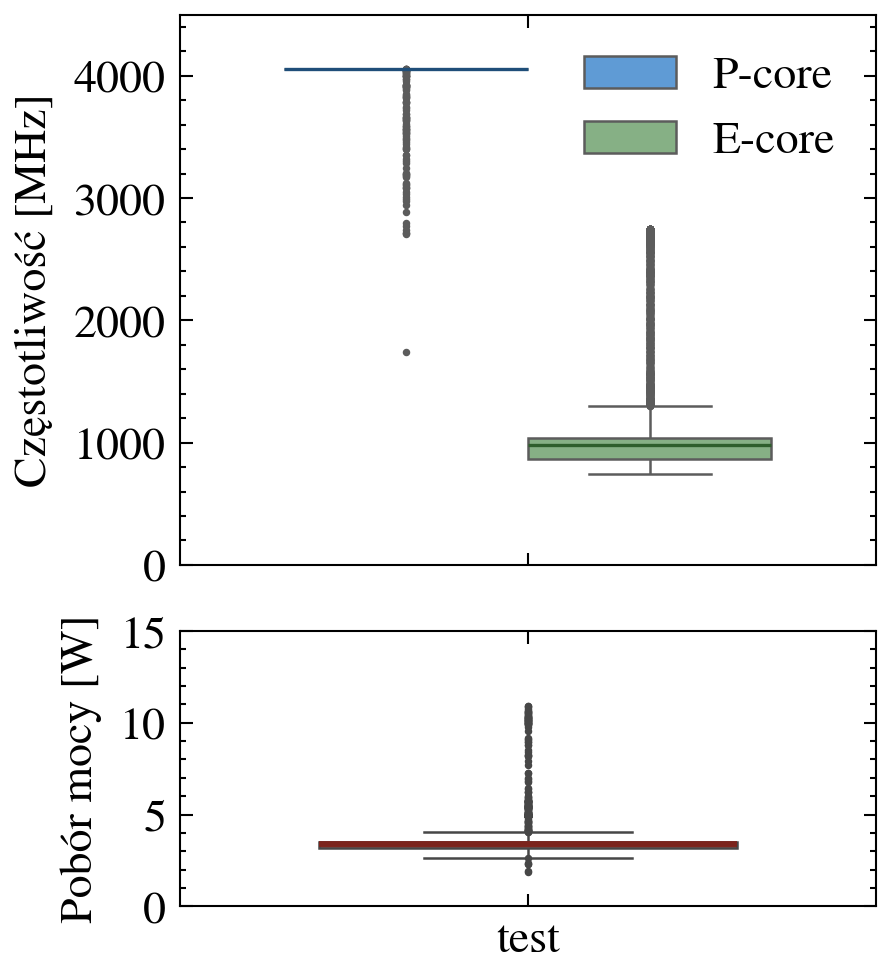

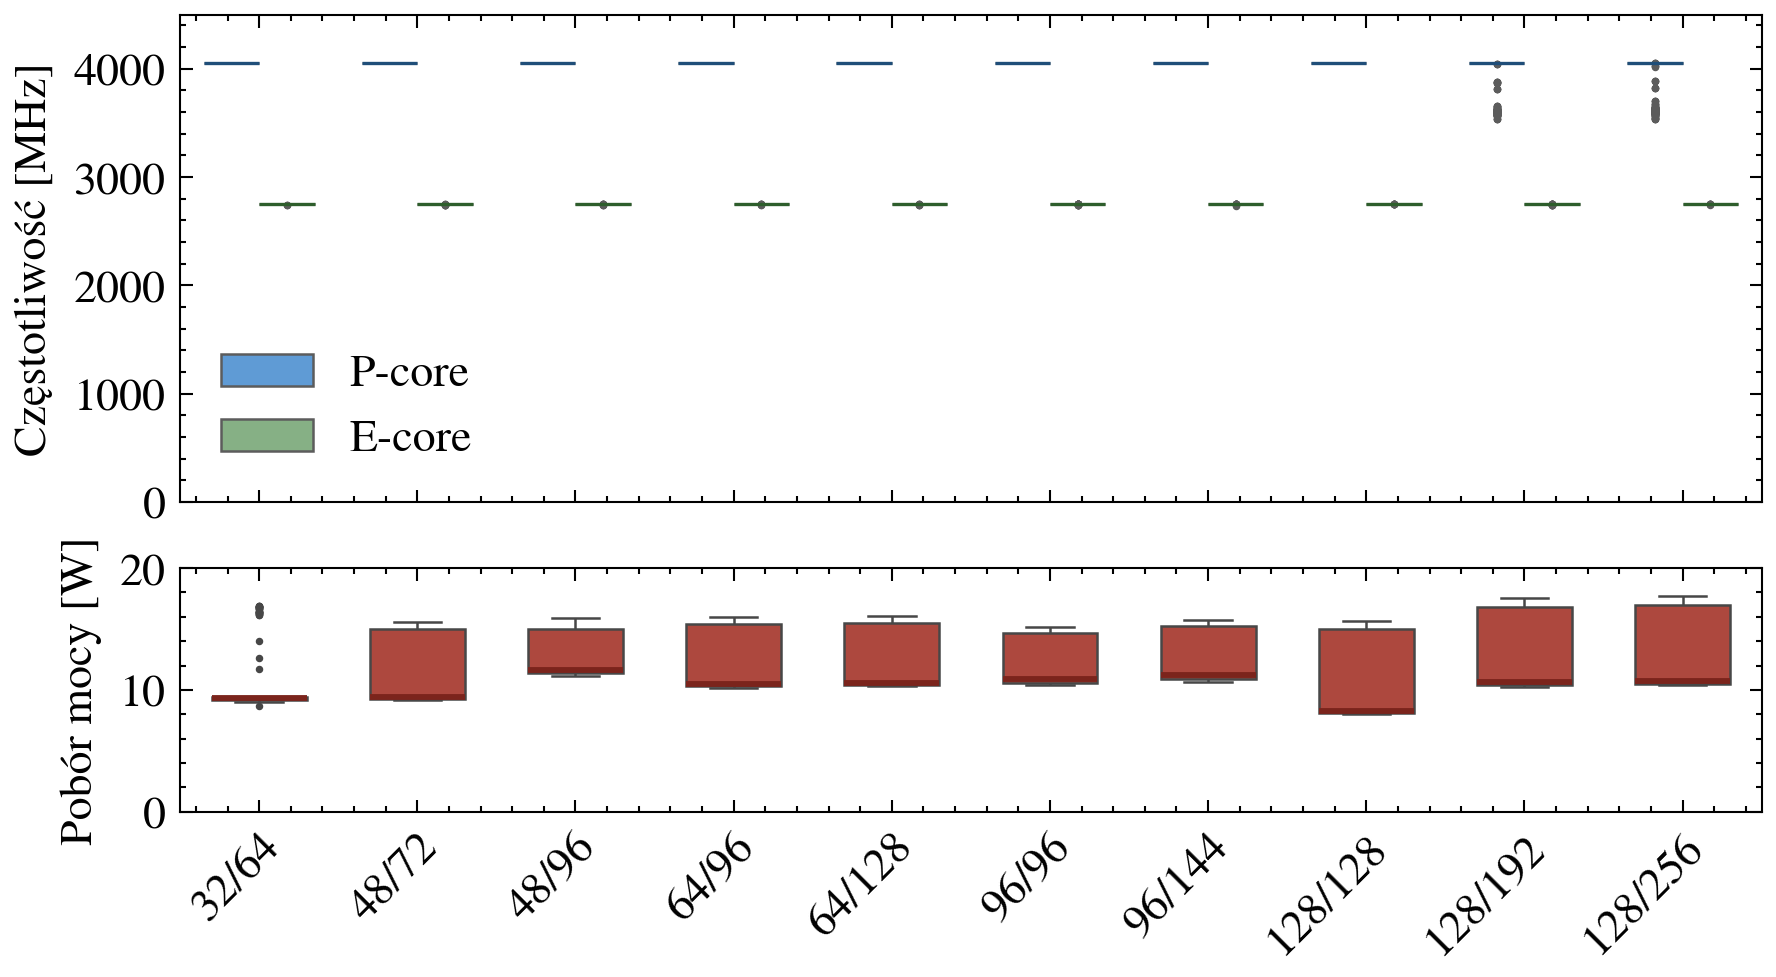

In [12]:
plot_turbostat([bench_turbostat], ['test'], [f'cpu{i}' for i in [1, 9]], 100, FIG_WIDTH / 4, "turbostat_bench")
plot_turbostat([system_turbostat], ['system'], [f'cpu{i}' for i in range(0, 16)], 100, FIG_WIDTH / 4,
               "turbostat_system")
plot_turbostat([bench_pm], ['test'], {
    "P-core": [f'cpu{i}' for i in range(4, 8)],
    "E-core": [f'cpu{i}' for i in range(0, 4)],
}, 5, FIG_WIDTH / 2, "pm_bench")
plot_turbostat(
    [system_pm_Speck32_64, system_pm_Speck48_72, system_pm_Speck48_96,
     system_pm_Speck64_96, system_pm_Speck64_128, system_pm_Speck96_96,
     system_pm_Speck96_144, system_pm_Speck128_128, system_pm_Speck128_192,
     system_pm_Speck128_256],
    ['32/64', '48/72', '48/96', '64/96', '64/128',
     '96/96', '96/144', '128/128', '128/192', '128/256'],
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
    5, FIG_WIDTH, "pm_system",
)

In [13]:
turbostat_backends = {
    "Scalar": scalar_turbostat,
    "SSE2": sse2_turbostat,
    "AVX2": avx2_turbostat,
    "AVX512": avx512_turbostat,
}
turbostat_backend_order = ["Scalar", "SSE2", "AVX2", "AVX512"]

pm_backends = {
    "Scalar": scalar_pm,
    "NEON": neon_pm,
}
pm_backend_order = ["Scalar", "NEON"]

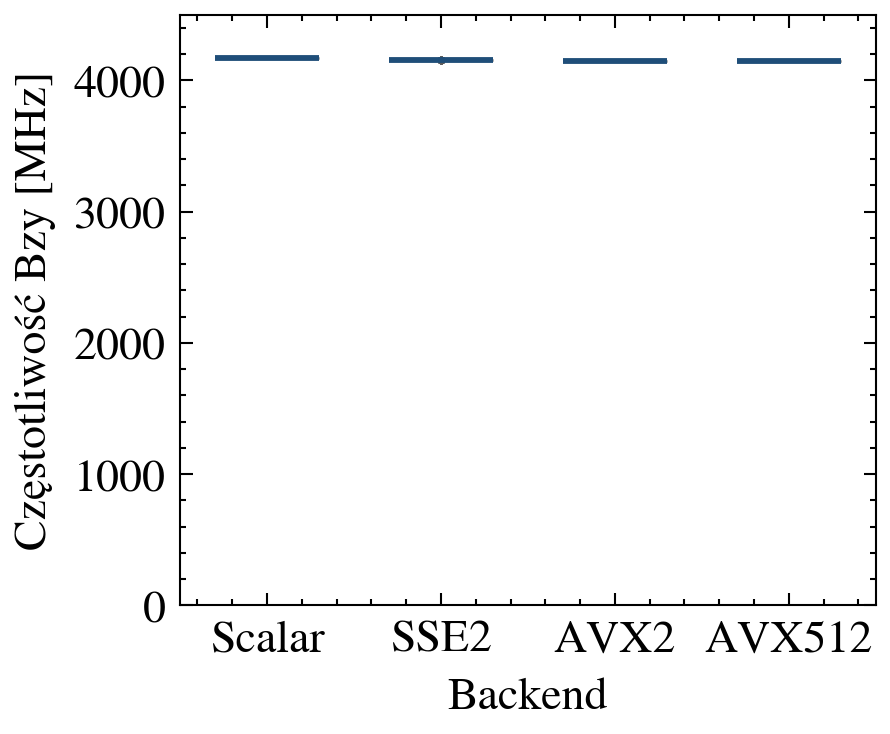

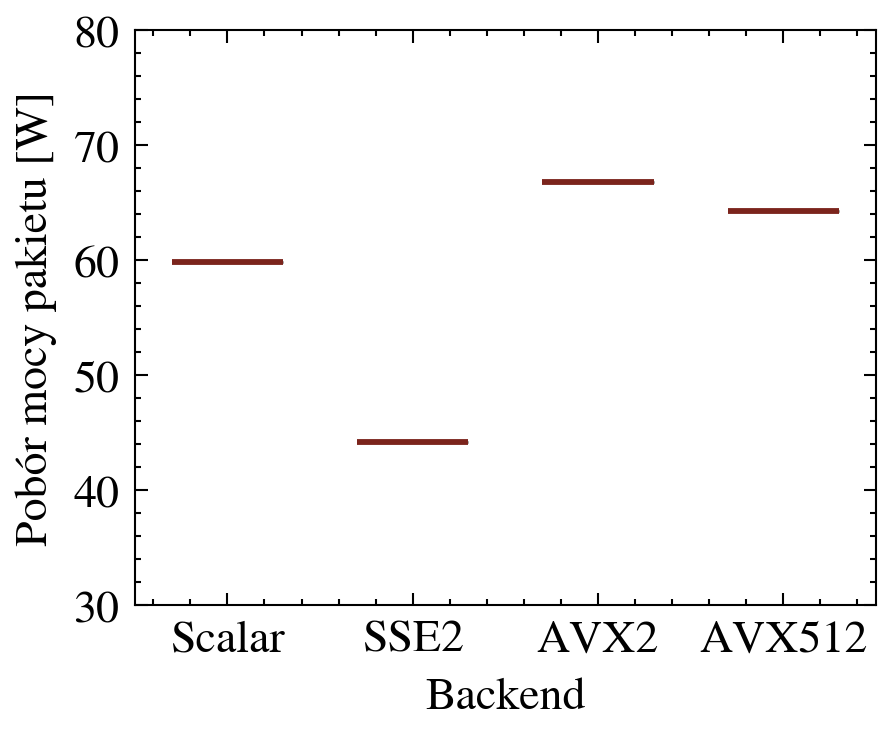

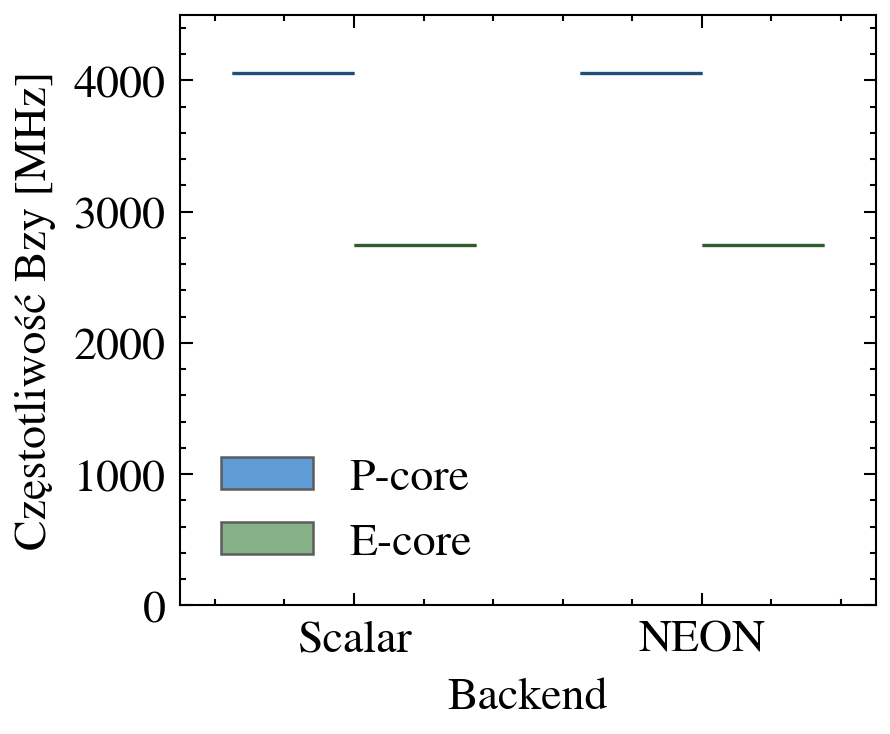

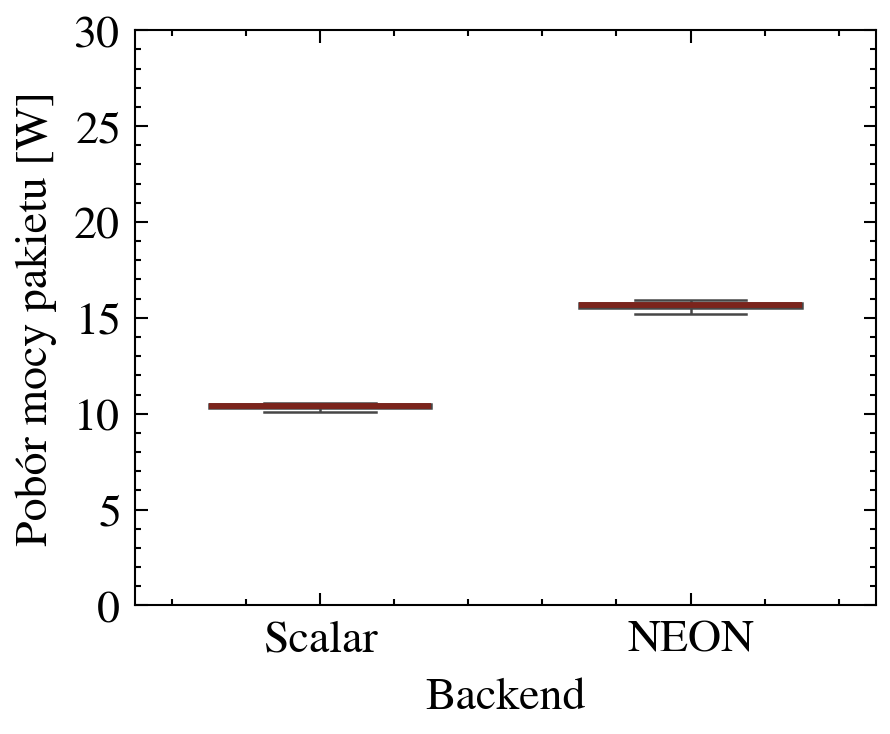

In [19]:
plot_compare(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
    'turbostat',
)

plot_compare(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
    'pm',
)

In [24]:
compare_backends(
    list(turbostat_backends.values()), turbostat_backend_order,
    [f'cpu{i}' for i in range(0, 16)],
)

compare_backends(
    list(pm_backends.values()), pm_backend_order,
    {
        "P-core": [f'cpu{i}' for i in range(4, 8)],
        "E-core": [f'cpu{i}' for i in range(0, 4)],
    },
)

Częstotliwość per backend:
  Scalar   4167 MHz  (+0.31% od średniej)
  SSE2     4152 MHz  (-0.05% od średniej)
  AVX2     4150 MHz  (-0.10% od średniej)
  AVX512   4148 MHz  (-0.15% od średniej)
Zakres: 4148–4167 MHz (rozrzut 19 MHz)
Średnia ze średnich: 4154 MHz, maks. odchył od średniej: 0.31%

Pobór mocy per backend:
  Scalar   59.85 W  (+1.77% od średniej)
  SSE2     44.23 W  (-24.79% od średniej)
  AVX2     66.84 W  (+13.65% od średniej)
  AVX512   64.32 W  (+9.37% od średniej)
Zakres: 44.23–66.84 W (rozrzut 22.61 W)
Średnia ze średnich: 58.81 W, maks. odchył od średniej: 24.79%

Częstotliwość [P-core] per backend:
  Scalar   4056 MHz  (+0.00% od średniej)
  NEON     4056 MHz  (+0.00% od średniej)
Zakres: 4056–4056 MHz (rozrzut 0 MHz)
Średnia ze średnich: 4056 MHz, maks. odchył od średniej: 0.00%

Częstotliwość [E-core] per backend:
  Scalar   2748 MHz  (+0.00% od średniej)
  NEON     2748 MHz  (+0.00% od średniej)
Zakres: 2748–2748 MHz (rozrzut 0 MHz)
Średnia ze średnich: 2748 MH